# Lookback Options: Interactive Analysis & Visualizations

**Product Type:** Path-Dependent Exotic Option  
**Key Feature:** "Perfect Hindsight" - captures optimal entry/exit timing

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Payoff Diagrams](#2-payoff-diagrams)
3. [Price Surfaces](#3-price-surfaces)
4. [Greeks Analysis](#4-greeks-analysis)
5. [Lookback vs Vanilla Comparison](#5-lookback-vs-vanilla-comparison)
6. [Monte Carlo Analysis](#6-monte-carlo-analysis)
7. [Sample Paths Visualization](#7-sample-paths-visualization)
8. [Reflection Principle Illustration](#8-reflection-principle-illustration)

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# Color scheme
COLORS = {
    'call_long': '#2ecc71',    # Green
    'call_short': '#e74c3c',   # Red
    'put_long': '#3498db',     # Blue
    'put_short': '#f39c12',    # Orange
    'lookback': '#9b59b6',     # Purple
    'vanilla': '#34495e',      # Dark gray
    'floating': '#2ecc71',     # Green
    'fixed': '#e74c3c',        # Red
    'path': '#3498db',         # Blue
    'extremum': '#e74c3c',     # Red
}

In [2]:
# Base parameters for analysis
BASE_PARAMS = {
    'S0': 100.0,      # Initial spot price
    'K': 100.0,       # Strike price (ATM)
    'T': 1.0,         # Time to maturity (1 year)
    'r': 0.05,        # Domestic risk-free rate (5%)
    'q': 0.02,        # Foreign rate / dividend yield (2%)
    'sigma': 0.20,    # Volatility (20%)
}

print("Base Parameters:")
print("-" * 40)
for key, value in BASE_PARAMS.items():
    print(f"{key:12s}: {value}")

Base Parameters:
----------------------------------------
S0          : 100.0
K           : 100.0
T           : 1.0
r           : 0.05
q           : 0.02
sigma       : 0.2


## Pricing Functions

In [3]:
def black_scholes_call(S, K, T, r, q, sigma):
    """Black-Scholes call option price."""
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def black_scholes_put(S, K, T, r, q, sigma):
    """Black-Scholes put option price."""
    if T <= 0:
        return max(K - S, 0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

def lookback_mc_price(S0, K, T, r, q, sigma, n_paths=100000, n_steps=252,
                      option_type='call', lookback_type='floating_strike', seed=42):
    """
    Monte Carlo pricer for lookback options.
    
    Parameters
    ----------
    lookback_type : str
        'floating_strike' or 'fixed_strike'
    
    Returns
    -------
    tuple : (price, std_error, paths, max_spots, min_spots)
    """
    np.random.seed(seed)
    
    if T <= 0:
        if lookback_type == 'floating_strike':
            return 0.0, 0.0, None, None, None  # S_T - m_T = 0 at T=0
        else:
            if option_type == 'call':
                return max(S0 - K, 0), 0.0, None, None, None
            return max(K - S0, 0), 0.0, None, None, None
    
    dt = T / n_steps
    drift = (r - q - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt)
    
    # Generate paths using antithetic variates
    Z = np.random.standard_normal((n_paths // 2, n_steps))
    Z = np.vstack([Z, -Z])  # Antithetic
    
    log_returns = drift + diffusion * Z
    log_paths = np.cumsum(log_returns, axis=1)
    
    # Include S0 in paths
    paths = np.column_stack([np.zeros(n_paths), log_paths])
    paths = S0 * np.exp(paths)
    
    # Compute extrema
    max_spots = np.max(paths, axis=1)
    min_spots = np.min(paths, axis=1)
    terminal_spots = paths[:, -1]
    
    # Compute payoffs based on lookback type
    if lookback_type == 'floating_strike':
        if option_type == 'call':
            # Floating strike call: S_T - min(S_t)
            payoffs = terminal_spots - min_spots
        else:
            # Floating strike put: max(S_t) - S_T
            payoffs = max_spots - terminal_spots
    else:  # fixed_strike
        if option_type == 'call':
            # Fixed strike call: max(max(S_t) - K, 0)
            payoffs = np.maximum(max_spots - K, 0)
        else:
            # Fixed strike put: max(K - min(S_t), 0)
            payoffs = np.maximum(K - min_spots, 0)
    
    # Discount
    discounted = np.exp(-r * T) * payoffs
    price = np.mean(discounted)
    std_error = np.std(discounted) / np.sqrt(n_paths)
    
    return price, std_error, paths, max_spots, min_spots

## 2. Payoff Diagrams

Visualizing the payoff structure for lookback options.

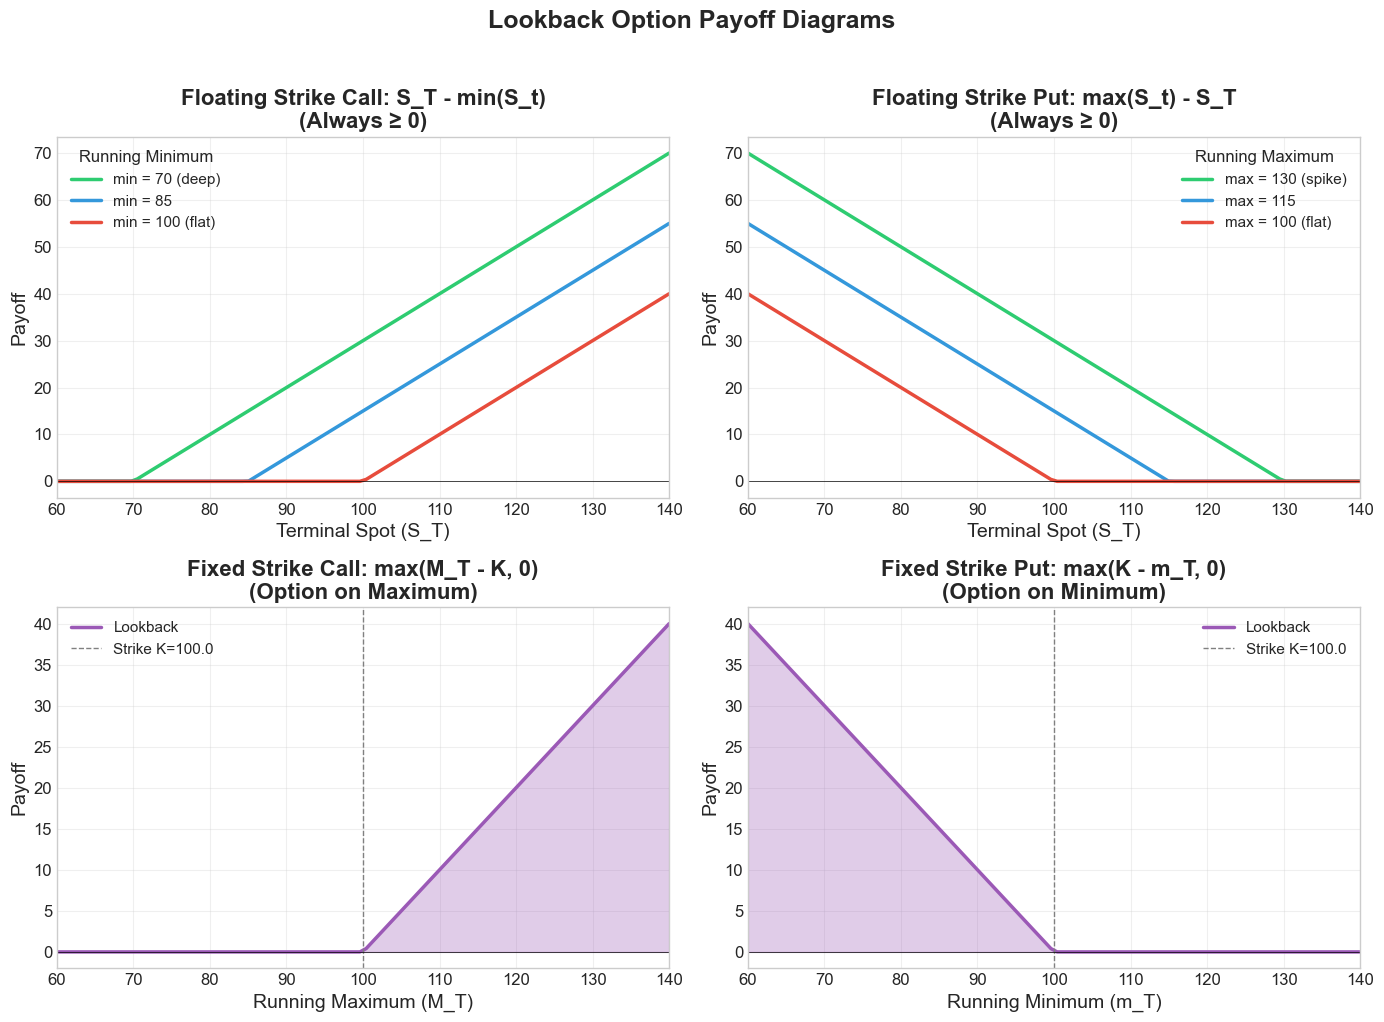

In [4]:
def plot_lookback_payoff_diagrams(save_fig: bool = False):
    """
    Plot payoff diagrams for lookback options.
    
    Note: For lookback options, payoff depends on multiple variables
    (S_T, M_T, m_T), so we show different scenarios.
    """
    K = BASE_PARAMS['K']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # --- Floating Strike Call: Payoff = S_T - m_T ---
    ax = axes[0, 0]
    terminal_spots = np.linspace(60, 140, 100)
    
    # Different minimum scenarios
    for m_T, color, label in [(70, '#2ecc71', 'min = 70 (deep)'),
                              (85, '#3498db', 'min = 85'),
                              (100, '#e74c3c', 'min = 100 (flat)')]:
        payoff = np.maximum(terminal_spots - m_T, 0)  # Always >= 0
        ax.plot(terminal_spots, payoff, color=color, linewidth=2.5, label=label)
    
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Terminal Spot (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Floating Strike Call: S_T - min(S_t)\n(Always ≥ 0)', fontweight='bold')
    ax.legend(title='Running Minimum')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(60, 140)
    
    # --- Floating Strike Put: Payoff = M_T - S_T ---
    ax = axes[0, 1]
    
    for M_T, color, label in [(130, '#2ecc71', 'max = 130 (spike)'),
                              (115, '#3498db', 'max = 115'),
                              (100, '#e74c3c', 'max = 100 (flat)')]:
        payoff = np.maximum(M_T - terminal_spots, 0)  # Always >= 0
        ax.plot(terminal_spots, payoff, color=color, linewidth=2.5, label=label)
    
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Terminal Spot (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Floating Strike Put: max(S_t) - S_T\n(Always ≥ 0)', fontweight='bold')
    ax.legend(title='Running Maximum')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(60, 140)
    
    # --- Fixed Strike Call: Payoff = max(M_T - K, 0) ---
    ax = axes[1, 0]
    max_spots = np.linspace(60, 140, 100)
    
    payoff = np.maximum(max_spots - K, 0)
    ax.plot(max_spots, payoff, color=COLORS['lookback'], linewidth=2.5, label='Lookback')
    
    # Compare with vanilla
    vanilla_payoff = np.maximum(max_spots - K, 0)  # Same formula, different underlying
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(max_spots, 0, payoff, alpha=0.3, color=COLORS['lookback'])
    
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Running Maximum (M_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Fixed Strike Call: max(M_T - K, 0)\n(Option on Maximum)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(60, 140)
    
    # --- Fixed Strike Put: Payoff = max(K - m_T, 0) ---
    ax = axes[1, 1]
    min_spots = np.linspace(60, 140, 100)
    
    payoff = np.maximum(K - min_spots, 0)
    ax.plot(min_spots, payoff, color=COLORS['lookback'], linewidth=2.5, label='Lookback')
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(min_spots, 0, payoff, alpha=0.3, color=COLORS['lookback'])
    
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Running Minimum (m_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Fixed Strike Put: max(K - m_T, 0)\n(Option on Minimum)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(60, 140)
    
    plt.suptitle('Lookback Option Payoff Diagrams', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_fig:
        plt.savefig('lookback_payoff_diagrams.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_lookback_payoff_diagrams(save_fig=False)

## 3. Price Surfaces

3D visualization of option price as a function of spot and time/volatility.

Computing prices (this may take a moment)...
Done!


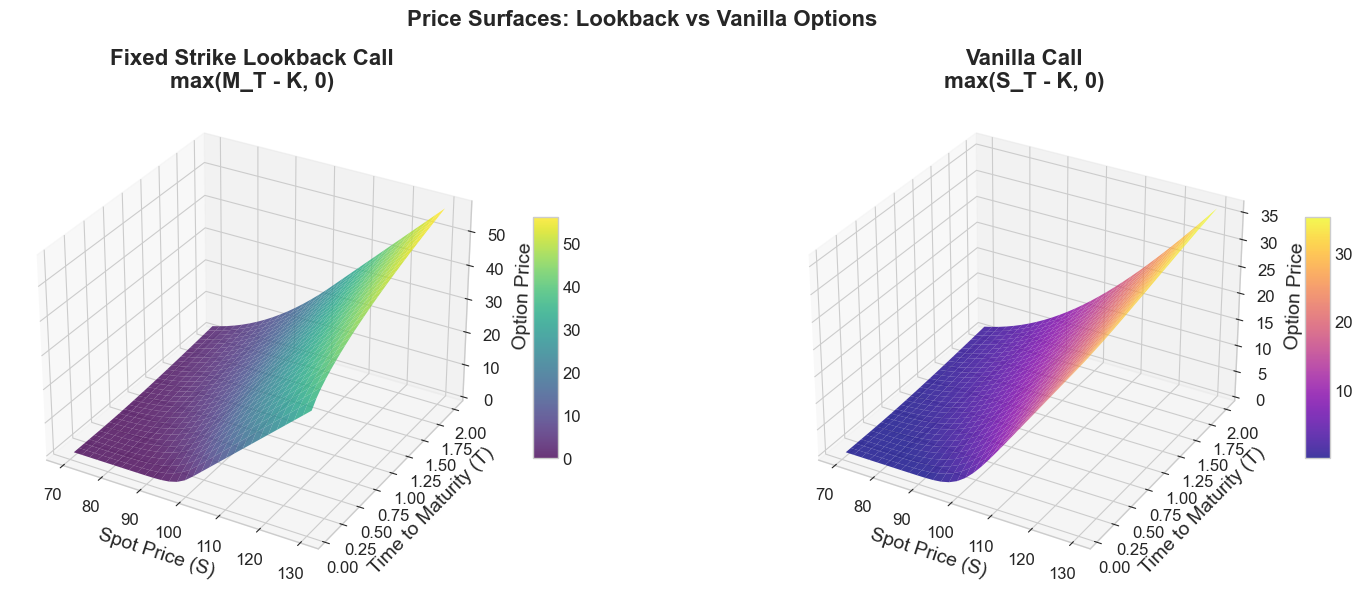

In [5]:
def plot_price_surface_spot_time(save_fig: bool = False):
    """
    Plot 3D price surface: Price vs Spot vs Time to Maturity.
    Comparing Lookback vs Vanilla.
    """
    K = BASE_PARAMS['K']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(70, 130, 30)
    times = np.linspace(0.05, 2.0, 30)
    S_grid, T_grid = np.meshgrid(spots, times)
    
    prices_lookback = np.zeros_like(S_grid)
    prices_vanilla = np.zeros_like(S_grid)
    
    print("Computing prices (this may take a moment)...")
    for i in range(len(times)):
        for j in range(len(spots)):
            # Use fewer paths for speed in surface plot
            lb_price, _, _, _, _ = lookback_mc_price(
                spots[j], K, times[i], r, q, sigma, 
                n_paths=10000, n_steps=50, lookback_type='fixed_strike'
            )
            prices_lookback[i, j] = lb_price
            prices_vanilla[i, j] = black_scholes_call(spots[j], K, times[i], r, q, sigma)
    print("Done!")
    
    fig = plt.figure(figsize=(16, 6))
    
    # Lookback Call Surface
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(S_grid, T_grid, prices_lookback, cmap=cm.viridis, alpha=0.8)
    ax1.set_xlabel('Spot Price (S)')
    ax1.set_ylabel('Time to Maturity (T)')
    ax1.set_zlabel('Option Price')
    ax1.set_title('Fixed Strike Lookback Call\nmax(M_T - K, 0)', fontweight='bold')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
    
    # Vanilla Call Surface
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(S_grid, T_grid, prices_vanilla, cmap=cm.plasma, alpha=0.8)
    ax2.set_xlabel('Spot Price (S)')
    ax2.set_ylabel('Time to Maturity (T)')
    ax2.set_zlabel('Option Price')
    ax2.set_title('Vanilla Call\nmax(S_T - K, 0)', fontweight='bold')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
    
    plt.suptitle('Price Surfaces: Lookback vs Vanilla Options', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('lookback_price_surface.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_price_surface_spot_time(save_fig=False)

Computing prices across volatilities...
Done!


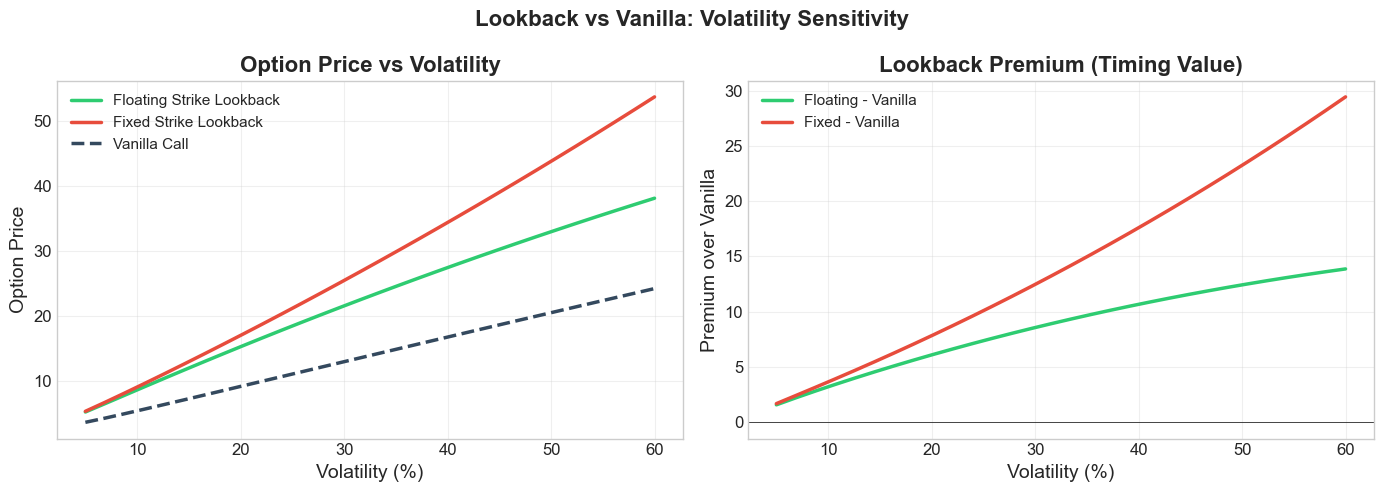

In [6]:
def plot_price_vs_vol(save_fig: bool = False):
    """
    Plot option price vs volatility for lookback and vanilla.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    
    vols = np.linspace(0.05, 0.60, 30)
    
    lookback_float_prices = []
    lookback_fixed_prices = []
    vanilla_prices = []
    
    print("Computing prices across volatilities...")
    for sigma in vols:
        float_price, _, _, _, _ = lookback_mc_price(
            S0, K, T, r, q, sigma, n_paths=20000, lookback_type='floating_strike'
        )
        fixed_price, _, _, _, _ = lookback_mc_price(
            S0, K, T, r, q, sigma, n_paths=20000, lookback_type='fixed_strike'
        )
        vanilla_price = black_scholes_call(S0, K, T, r, q, sigma)
        
        lookback_float_prices.append(float_price)
        lookback_fixed_prices.append(fixed_price)
        vanilla_prices.append(vanilla_price)
    print("Done!")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Price vs Vol
    ax = axes[0]
    ax.plot(vols * 100, lookback_float_prices, color=COLORS['floating'], linewidth=2.5, 
            label='Floating Strike Lookback')
    ax.plot(vols * 100, lookback_fixed_prices, color=COLORS['fixed'], linewidth=2.5, 
            label='Fixed Strike Lookback')
    ax.plot(vols * 100, vanilla_prices, color=COLORS['vanilla'], linewidth=2.5, 
            linestyle='--', label='Vanilla Call')
    ax.set_xlabel('Volatility (%)')
    ax.set_ylabel('Option Price')
    ax.set_title('Option Price vs Volatility', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Premium over vanilla
    ax = axes[1]
    premium_float = np.array(lookback_float_prices) - np.array(vanilla_prices)
    premium_fixed = np.array(lookback_fixed_prices) - np.array(vanilla_prices)
    
    ax.plot(vols * 100, premium_float, color=COLORS['floating'], linewidth=2.5, 
            label='Floating - Vanilla')
    ax.plot(vols * 100, premium_fixed, color=COLORS['fixed'], linewidth=2.5, 
            label='Fixed - Vanilla')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Volatility (%)')
    ax.set_ylabel('Premium over Vanilla')
    ax.set_title('Lookback Premium (Timing Value)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('Lookback vs Vanilla: Volatility Sensitivity', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('lookback_vol_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_price_vs_vol(save_fig=False)

## 4. Greeks Analysis

Visualization of Delta, Gamma, Vega for lookback options.

In [7]:
def compute_lookback_greeks_fd(S0, K, T, r, q, sigma, lookback_type='floating_strike', epsilon=0.01):
    """
    Compute Greeks for lookback options using finite differences.
    """
    def price_fn(S):
        p, _, _, _, _ = lookback_mc_price(S, K, T, r, q, sigma, n_paths=30000, 
                                          lookback_type=lookback_type, seed=42)
        return p
    
    base_price = price_fn(S0)
    
    # Delta: dV/dS
    dS = S0 * epsilon
    V_up = price_fn(S0 + dS)
    V_down = price_fn(S0 - dS)
    delta = (V_up - V_down) / (2 * dS)
    
    # Gamma: d²V/dS²
    gamma = (V_up - 2 * base_price + V_down) / (dS ** 2)
    
    # Vega: dV/dσ
    d_sigma = 0.01
    V_vol_up, _, _, _, _ = lookback_mc_price(S0, K, T, r, q, sigma + d_sigma, 
                                              n_paths=30000, lookback_type=lookback_type, seed=42)
    V_vol_down, _, _, _, _ = lookback_mc_price(S0, K, T, r, q, sigma - d_sigma,
                                                n_paths=30000, lookback_type=lookback_type, seed=42)
    vega = (V_vol_up - V_vol_down) / 2
    
    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'price': base_price}

def compute_vanilla_greeks_fd(S0, K, T, r, q, sigma, epsilon=0.01):
    """
    Compute Greeks for vanilla options using finite differences.
    """
    base_price = black_scholes_call(S0, K, T, r, q, sigma)
    dS = S0 * epsilon
    
    V_up = black_scholes_call(S0 + dS, K, T, r, q, sigma)
    V_down = black_scholes_call(S0 - dS, K, T, r, q, sigma)
    delta = (V_up - V_down) / (2 * dS)
    gamma = (V_up - 2 * base_price + V_down) / (dS ** 2)
    
    d_sigma = 0.01
    V_vol_up = black_scholes_call(S0, K, T, r, q, sigma + d_sigma)
    V_vol_down = black_scholes_call(S0, K, T, r, q, sigma - d_sigma)
    vega = (V_vol_up - V_vol_down) / 2
    
    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'price': base_price}

Computing Greeks (this may take a minute)...
  Spot 1/15: S = 80
  Spot 2/15: S = 83
  Spot 3/15: S = 86
  Spot 4/15: S = 89
  Spot 5/15: S = 91
  Spot 6/15: S = 94
  Spot 7/15: S = 97
  Spot 8/15: S = 100
  Spot 9/15: S = 103
  Spot 10/15: S = 106
  Spot 11/15: S = 109
  Spot 12/15: S = 111
  Spot 13/15: S = 114
  Spot 14/15: S = 117
  Spot 15/15: S = 120
Done!


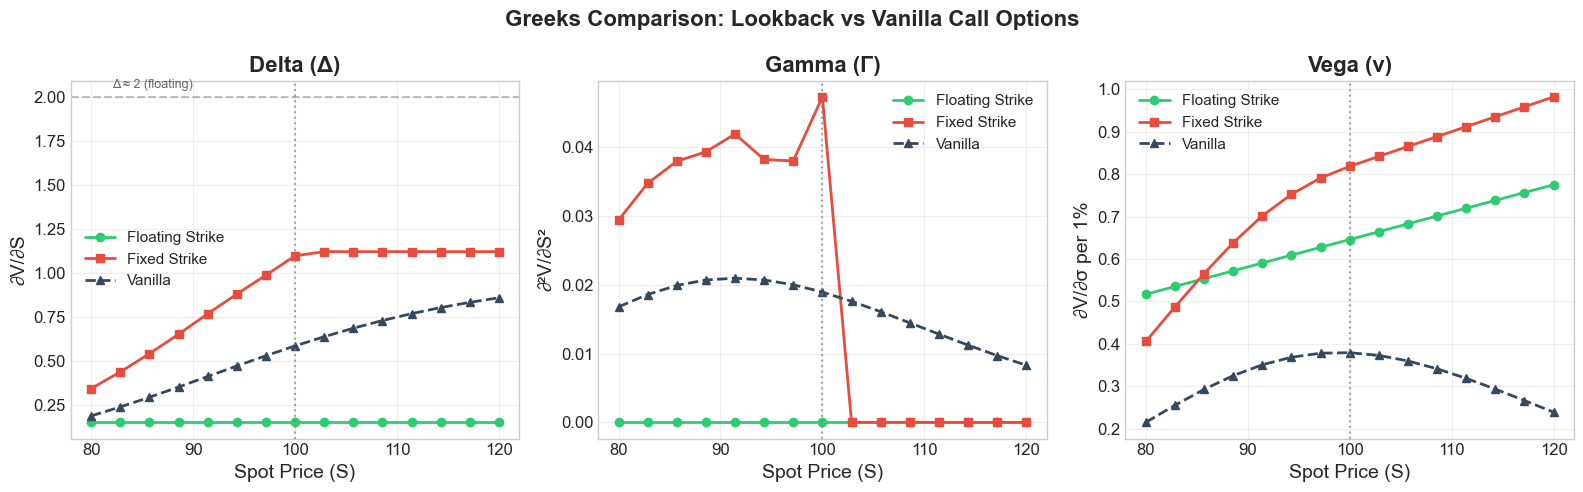

In [8]:
def plot_greeks_comparison(save_fig: bool = False):
    """
    Compare Greeks for lookback vs vanilla options.
    """
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(80, 120, 15)
    
    lookback_float_greeks = {'delta': [], 'gamma': [], 'vega': []}
    lookback_fixed_greeks = {'delta': [], 'gamma': [], 'vega': []}
    vanilla_greeks = {'delta': [], 'gamma': [], 'vega': []}
    
    print("Computing Greeks (this may take a minute)...")
    for i, S in enumerate(spots):
        print(f"  Spot {i+1}/{len(spots)}: S = {S:.0f}")
        
        fg = compute_lookback_greeks_fd(S, K, T, r, q, sigma, 'floating_strike')
        xg = compute_lookback_greeks_fd(S, K, T, r, q, sigma, 'fixed_strike')
        vg = compute_vanilla_greeks_fd(S, K, T, r, q, sigma)
        
        for greek in ['delta', 'gamma', 'vega']:
            lookback_float_greeks[greek].append(fg[greek])
            lookback_fixed_greeks[greek].append(xg[greek])
            vanilla_greeks[greek].append(vg[greek])
    print("Done!")
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    greek_info = [
        ('delta', 'Delta (Δ)', '∂V/∂S'),
        ('gamma', 'Gamma (Γ)', '∂²V/∂S²'),
        ('vega', 'Vega (ν)', '∂V/∂σ per 1%'),
    ]
    
    for idx, (greek, title, ylabel) in enumerate(greek_info):
        ax = axes[idx]
        ax.plot(spots, lookback_float_greeks[greek], 'o-', color=COLORS['floating'], 
                linewidth=2, markersize=6, label='Floating Strike')
        ax.plot(spots, lookback_fixed_greeks[greek], 's-', color=COLORS['fixed'], 
                linewidth=2, markersize=6, label='Fixed Strike')
        ax.plot(spots, vanilla_greeks[greek], '^--', color=COLORS['vanilla'], 
                linewidth=2, markersize=6, label='Vanilla')
        ax.axvline(x=K, color='gray', linestyle=':', alpha=0.7)
        ax.set_xlabel('Spot Price (S)')
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add annotation for delta
        if greek == 'delta':
            ax.axhline(y=2, color='gray', linestyle='--', alpha=0.5)
            ax.text(82, 2.05, 'Δ ≈ 2 (floating)', fontsize=9, alpha=0.7)
    
    plt.suptitle('Greeks Comparison: Lookback vs Vanilla Call Options', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('lookback_greeks_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_greeks_comparison(save_fig=False)

## 5. Lookback vs Vanilla Comparison

Demonstrating that lookback options are always more expensive than vanilla.

Computing prices across strikes...
Done!


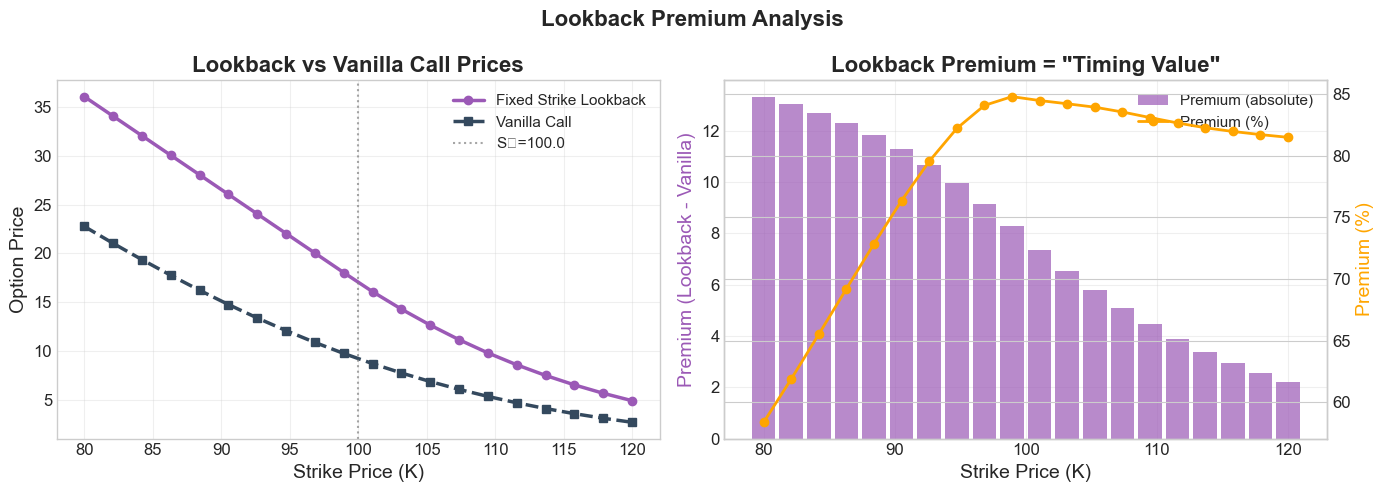

In [9]:
def plot_lookback_vs_vanilla(save_fig: bool = False):
    """
    Compare lookback vs vanilla prices across strikes.
    """
    S0 = BASE_PARAMS['S0']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    strikes = np.linspace(80, 120, 20)
    
    lookback_prices = []
    vanilla_prices = []
    
    print("Computing prices across strikes...")
    for K in strikes:
        lb_price, _, _, _, _ = lookback_mc_price(
            S0, K, T, r, q, sigma, n_paths=50000, lookback_type='fixed_strike'
        )
        van_price = black_scholes_call(S0, K, T, r, q, sigma)
        
        lookback_prices.append(lb_price)
        vanilla_prices.append(van_price)
    print("Done!")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Price comparison
    ax = axes[0]
    ax.plot(strikes, lookback_prices, 'o-', color=COLORS['lookback'], linewidth=2.5, 
            markersize=6, label='Fixed Strike Lookback')
    ax.plot(strikes, vanilla_prices, 's--', color=COLORS['vanilla'], linewidth=2.5, 
            markersize=6, label='Vanilla Call')
    ax.axvline(x=S0, color='gray', linestyle=':', alpha=0.7, label=f'S₀={S0}')
    ax.set_xlabel('Strike Price (K)')
    ax.set_ylabel('Option Price')
    ax.set_title('Lookback vs Vanilla Call Prices', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Premium (timing value)
    ax = axes[1]
    premium = np.array(lookback_prices) - np.array(vanilla_prices)
    premium_pct = premium / np.array(vanilla_prices) * 100
    
    ax.bar(strikes, premium, color=COLORS['lookback'], alpha=0.7, width=1.8, label='Premium (absolute)')
    ax2 = ax.twinx()
    ax2.plot(strikes, premium_pct, 'o-', color='orange', linewidth=2, markersize=6, label='Premium (%)')
    
    ax.set_xlabel('Strike Price (K)')
    ax.set_ylabel('Premium (Lookback - Vanilla)', color=COLORS['lookback'])
    ax2.set_ylabel('Premium (%)', color='orange')
    ax.set_title('Lookback Premium = "Timing Value"', fontweight='bold')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    plt.suptitle('Lookback Premium Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('lookback_vs_vanilla.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_lookback_vs_vanilla(save_fig=False)

## 6. Monte Carlo Analysis

Convergence and distribution analysis.

Computing convergence...
Done!


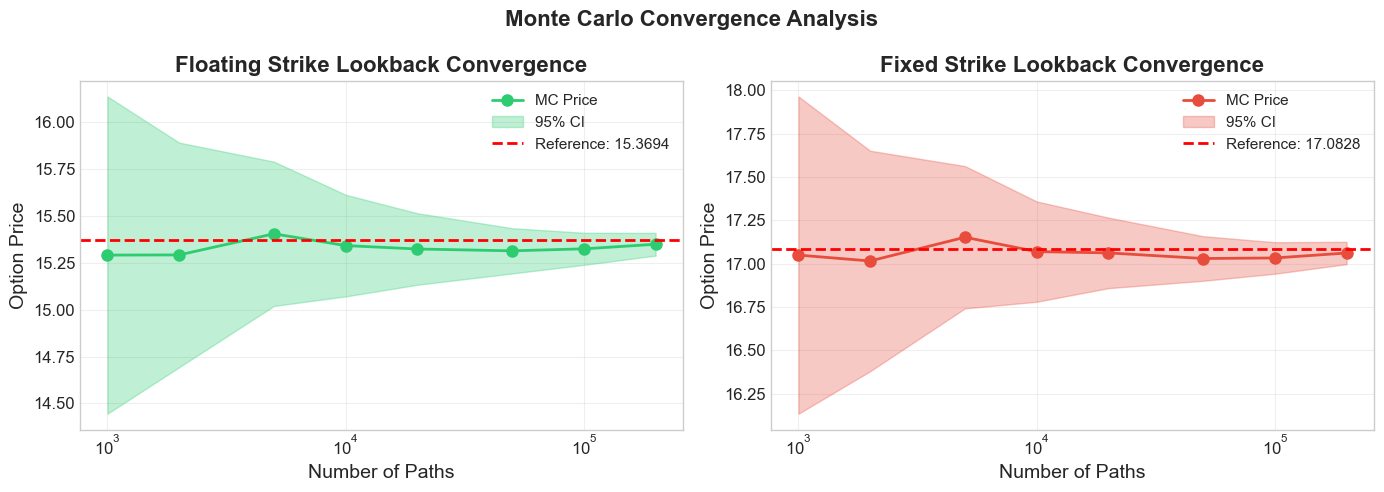

In [10]:
def plot_mc_convergence(save_fig: bool = False):
    """
    Plot Monte Carlo convergence for lookback options.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    path_counts = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000]
    
    prices_float = []
    prices_fixed = []
    se_float = []
    se_fixed = []
    
    print("Computing convergence...")
    for n_paths in path_counts:
        pf, sf, _, _, _ = lookback_mc_price(S0, K, T, r, q, sigma, n_paths=n_paths, 
                                            lookback_type='floating_strike', seed=42)
        px, sx, _, _, _ = lookback_mc_price(S0, K, T, r, q, sigma, n_paths=n_paths, 
                                            lookback_type='fixed_strike', seed=42)
        prices_float.append(pf)
        prices_fixed.append(px)
        se_float.append(sf)
        se_fixed.append(sx)
    print("Done!")
    
    # Reference prices (high accuracy)
    ref_float, _, _, _, _ = lookback_mc_price(S0, K, T, r, q, sigma, n_paths=500000, 
                                              lookback_type='floating_strike', seed=42)
    ref_fixed, _, _, _, _ = lookback_mc_price(S0, K, T, r, q, sigma, n_paths=500000, 
                                              lookback_type='fixed_strike', seed=42)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Floating strike convergence
    ax = axes[0]
    ax.plot(path_counts, prices_float, 'o-', color=COLORS['floating'], linewidth=2, 
            markersize=8, label='MC Price')
    ax.fill_between(path_counts, 
                    np.array(prices_float) - 1.96 * np.array(se_float),
                    np.array(prices_float) + 1.96 * np.array(se_float),
                    alpha=0.3, color=COLORS['floating'], label='95% CI')
    ax.axhline(y=ref_float, color='red', linestyle='--', linewidth=2, 
               label=f'Reference: {ref_float:.4f}')
    ax.set_xscale('log')
    ax.set_xlabel('Number of Paths')
    ax.set_ylabel('Option Price')
    ax.set_title('Floating Strike Lookback Convergence', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Fixed strike convergence
    ax = axes[1]
    ax.plot(path_counts, prices_fixed, 'o-', color=COLORS['fixed'], linewidth=2, 
            markersize=8, label='MC Price')
    ax.fill_between(path_counts, 
                    np.array(prices_fixed) - 1.96 * np.array(se_fixed),
                    np.array(prices_fixed) + 1.96 * np.array(se_fixed),
                    alpha=0.3, color=COLORS['fixed'], label='95% CI')
    ax.axhline(y=ref_fixed, color='red', linestyle='--', linewidth=2, 
               label=f'Reference: {ref_fixed:.4f}')
    ax.set_xscale('log')
    ax.set_xlabel('Number of Paths')
    ax.set_ylabel('Option Price')
    ax.set_title('Fixed Strike Lookback Convergence', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('Monte Carlo Convergence Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('lookback_mc_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_mc_convergence(save_fig=False)

## 7. Sample Paths Visualization

Visualizing simulated paths with running extrema.

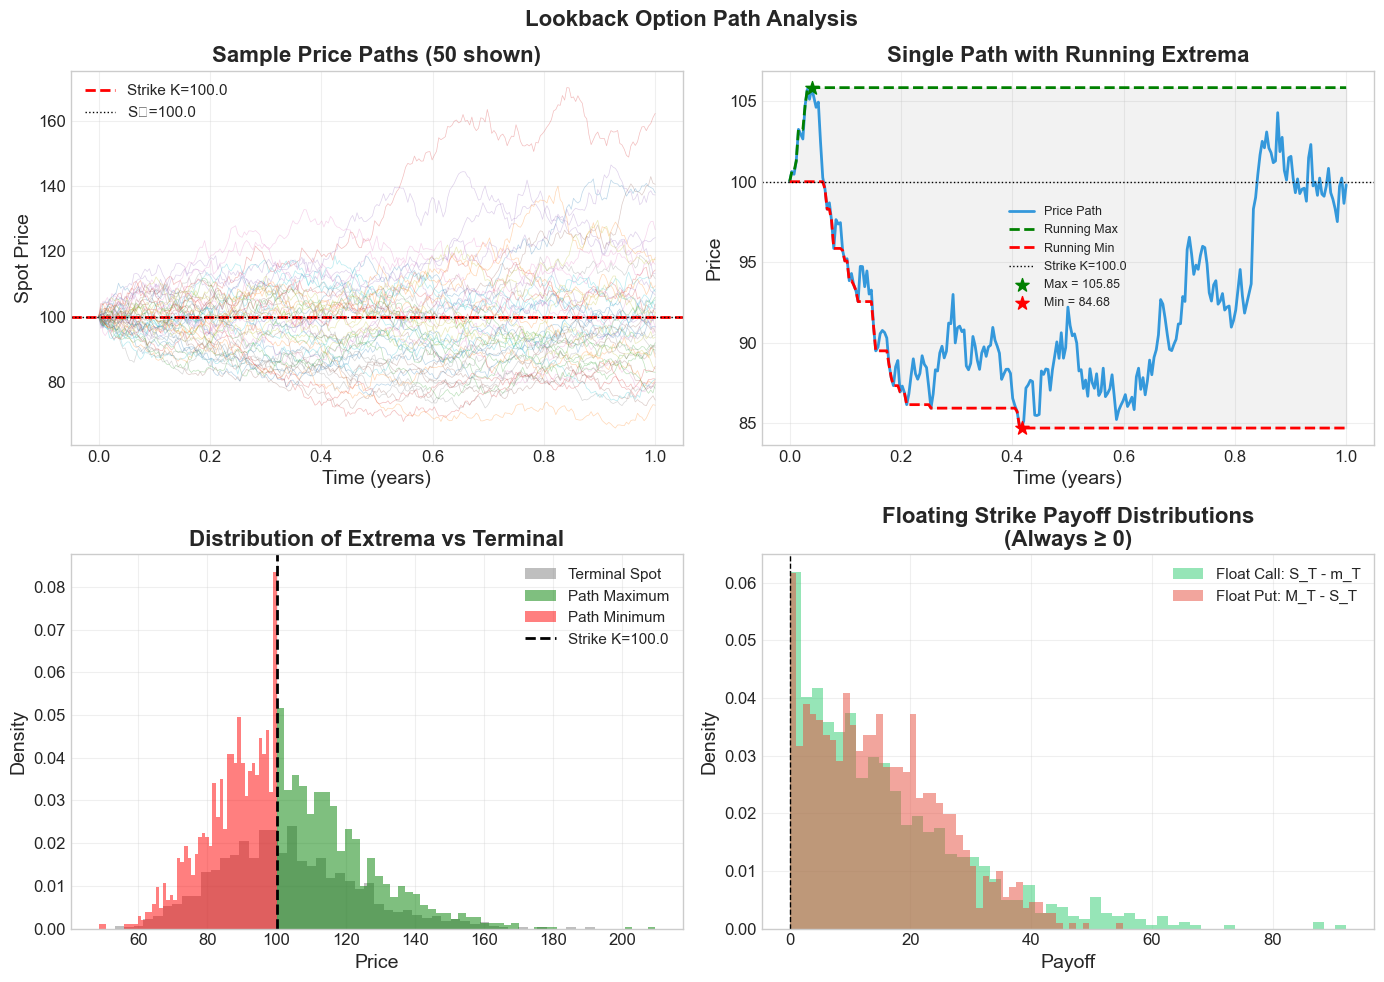

In [11]:
def plot_sample_paths_with_extrema(save_fig: bool = False):
    """
    Visualize sample paths with their running maximum and minimum.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    # Generate paths
    _, _, paths, max_spots, min_spots = lookback_mc_price(
        S0, K, T, r, q, sigma, n_paths=1000, n_steps=252, seed=42
    )
    
    times = np.linspace(0, T, paths.shape[1])
    terminal_spots = paths[:, -1]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Sample paths with many lines
    ax = axes[0, 0]
    for i in range(min(50, paths.shape[0])):
        ax.plot(times, paths[i, :], alpha=0.3, linewidth=0.5)
    ax.axhline(y=K, color='red', linestyle='--', linewidth=2, label=f'Strike K={K}')
    ax.axhline(y=S0, color='black', linestyle=':', linewidth=1, label=f'S₀={S0}')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Spot Price')
    ax.set_title('Sample Price Paths (50 shown)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Single path with running max/min
    ax = axes[0, 1]
    sample_path = paths[0, :]
    running_max = np.maximum.accumulate(sample_path)
    running_min = np.minimum.accumulate(sample_path)
    
    ax.plot(times, sample_path, color=COLORS['path'], linewidth=2, label='Price Path')
    ax.plot(times, running_max, color='green', linewidth=2, linestyle='--', label='Running Max')
    ax.plot(times, running_min, color='red', linewidth=2, linestyle='--', label='Running Min')
    ax.fill_between(times, running_min, running_max, alpha=0.1, color='gray')
    ax.axhline(y=K, color='black', linestyle=':', linewidth=1, label=f'Strike K={K}')
    
    # Mark extrema
    max_idx = np.argmax(sample_path)
    min_idx = np.argmin(sample_path)
    ax.scatter([times[max_idx]], [sample_path[max_idx]], s=100, c='green', 
               marker='*', zorder=5, label=f'Max = {sample_path[max_idx]:.2f}')
    ax.scatter([times[min_idx]], [sample_path[min_idx]], s=100, c='red', 
               marker='*', zorder=5, label=f'Min = {sample_path[min_idx]:.2f}')
    
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Price')
    ax.set_title('Single Path with Running Extrema', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Distribution of max, min, terminal
    ax = axes[1, 0]
    ax.hist(terminal_spots, bins=50, alpha=0.5, color='gray', label='Terminal Spot', density=True)
    ax.hist(max_spots, bins=50, alpha=0.5, color='green', label='Path Maximum', density=True)
    ax.hist(min_spots, bins=50, alpha=0.5, color='red', label='Path Minimum', density=True)
    ax.axvline(x=K, color='black', linestyle='--', linewidth=2, label=f'Strike K={K}')
    ax.set_xlabel('Price')
    ax.set_ylabel('Density')
    ax.set_title('Distribution of Extrema vs Terminal', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Payoff distributions
    ax = axes[1, 1]
    payoff_float_call = terminal_spots - min_spots  # Floating strike call
    payoff_float_put = max_spots - terminal_spots   # Floating strike put
    payoff_fixed_call = np.maximum(max_spots - K, 0)  # Fixed strike call
    
    ax.hist(payoff_float_call, bins=50, alpha=0.5, color=COLORS['floating'], 
            label='Float Call: S_T - m_T', density=True)
    ax.hist(payoff_float_put, bins=50, alpha=0.5, color=COLORS['fixed'], 
            label='Float Put: M_T - S_T', density=True)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Payoff')
    ax.set_ylabel('Density')
    ax.set_title('Floating Strike Payoff Distributions\n(Always ≥ 0)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('Lookback Option Path Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('lookback_sample_paths.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_sample_paths_with_extrema(save_fig=False)

## 8. Reflection Principle Illustration

Visual demonstration of the reflection principle for Brownian motion.

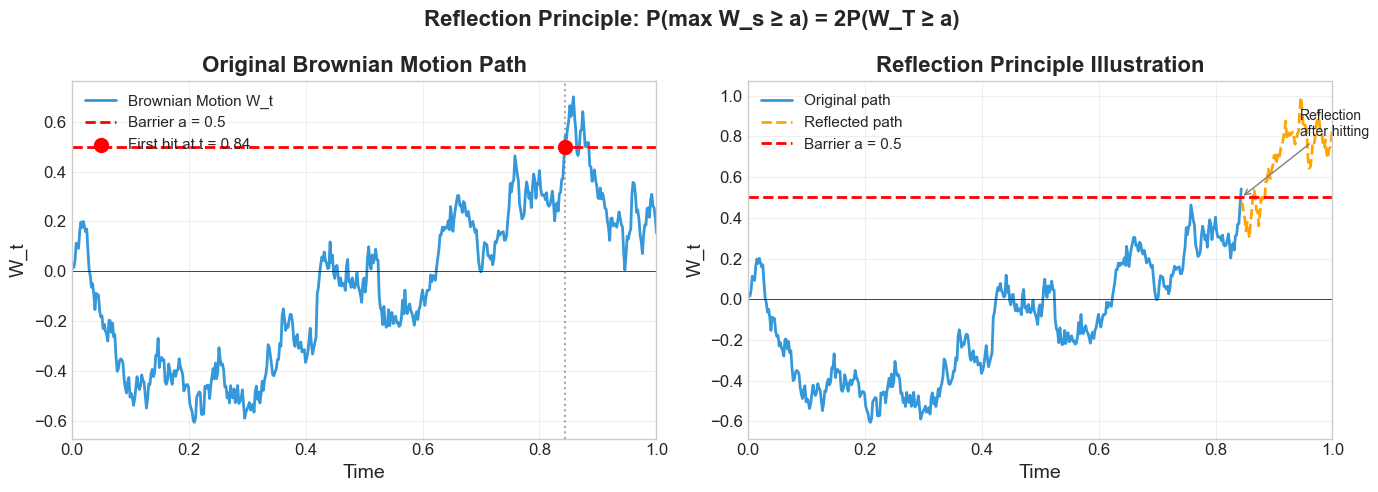

In [12]:
def plot_reflection_principle(save_fig: bool = False):
    """
    Illustrate the reflection principle for Brownian motion.
    
    The reflection principle states:
    P(max_{0≤s≤t} W_s ≥ a) = 2 * P(W_t ≥ a)
    """
    np.random.seed(42)
    
    T = 1.0
    n_steps = 500
    dt = T / n_steps
    times = np.linspace(0, T, n_steps + 1)
    
    # Generate a Brownian motion path
    dW = np.sqrt(dt) * np.random.randn(n_steps)
    W = np.zeros(n_steps + 1)
    W[1:] = np.cumsum(dW)
    
    # Set a barrier level
    barrier = 0.5
    
    # Find first hitting time
    hit_mask = W >= barrier
    if hit_mask.any():
        first_hit_idx = np.argmax(hit_mask)
        hit_time = times[first_hit_idx]
        
        # Create reflected path
        W_reflected = W.copy()
        W_reflected[first_hit_idx:] = 2 * barrier - W[first_hit_idx:]
    else:
        first_hit_idx = None
        W_reflected = W.copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Original path
    ax = axes[0]
    ax.plot(times, W, color=COLORS['path'], linewidth=2, label='Brownian Motion W_t')
    ax.axhline(y=barrier, color='red', linestyle='--', linewidth=2, label=f'Barrier a = {barrier}')
    ax.axhline(y=0, color='black', linewidth=0.5)
    if first_hit_idx is not None:
        ax.axvline(x=hit_time, color='gray', linestyle=':', alpha=0.7)
        ax.scatter([hit_time], [barrier], s=100, c='red', marker='o', zorder=5, 
                   label=f'First hit at t = {hit_time:.2f}')
    ax.set_xlabel('Time')
    ax.set_ylabel('W_t')
    ax.set_title('Original Brownian Motion Path', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, T)
    
    # Reflected path
    ax = axes[1]
    ax.plot(times[:first_hit_idx+1] if first_hit_idx else times, 
            W[:first_hit_idx+1] if first_hit_idx else W, 
            color=COLORS['path'], linewidth=2, label='Original path')
    if first_hit_idx is not None:
        ax.plot(times[first_hit_idx:], W_reflected[first_hit_idx:], 
                color='orange', linewidth=2, linestyle='--', label='Reflected path')
    ax.axhline(y=barrier, color='red', linestyle='--', linewidth=2, label=f'Barrier a = {barrier}')
    ax.axhline(y=0, color='black', linewidth=0.5)
    
    # Add annotation
    ax.annotate('Reflection\nafter hitting', xy=(hit_time, barrier), xytext=(hit_time + 0.1, barrier + 0.3),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
    
    ax.set_xlabel('Time')
    ax.set_ylabel('W_t')
    ax.set_title('Reflection Principle Illustration', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, T)
    
    plt.suptitle('Reflection Principle: P(max W_s ≥ a) = 2P(W_T ≥ a)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('reflection_principle.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_reflection_principle(save_fig=False)

## Summary Statistics

In [13]:
def print_summary_statistics():
    """
    Print comprehensive summary statistics for lookback options.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    # Compute prices
    vanilla_call = black_scholes_call(S0, K, T, r, q, sigma)
    vanilla_put = black_scholes_put(S0, K, T, r, q, sigma)
    
    float_call, float_call_se, _, _, _ = lookback_mc_price(
        S0, K, T, r, q, sigma, n_paths=200000, lookback_type='floating_strike', option_type='call'
    )
    float_put, float_put_se, _, _, _ = lookback_mc_price(
        S0, K, T, r, q, sigma, n_paths=200000, lookback_type='floating_strike', option_type='put'
    )
    fixed_call, fixed_call_se, _, _, _ = lookback_mc_price(
        S0, K, T, r, q, sigma, n_paths=200000, lookback_type='fixed_strike', option_type='call'
    )
    fixed_put, fixed_put_se, _, _, _ = lookback_mc_price(
        S0, K, T, r, q, sigma, n_paths=200000, lookback_type='fixed_strike', option_type='put'
    )
    
    print("=" * 70)
    print("LOOKBACK OPTIONS: COMPREHENSIVE SUMMARY")
    print("=" * 70)
    print(f"\nBase Parameters: S₀={S0}, K={K}, T={T}, r={r*100:.1f}%, q={q*100:.1f}%, σ={sigma*100:.0f}%")
    
    print("\n" + "-" * 70)
    print("OPTION PRICES")
    print("-" * 70)
    print(f"{'Type':<30} {'Call':>15} {'Put':>15}")
    print("-" * 70)
    print(f"{'Vanilla (BSM)':<30} {vanilla_call:>15.4f} {vanilla_put:>15.4f}")
    print(f"{'Floating Strike Lookback':<30} {float_call:>15.4f} {float_put:>15.4f}")
    print(f"{'Fixed Strike Lookback':<30} {fixed_call:>15.4f} {fixed_put:>15.4f}")
    
    print("\n" + "-" * 70)
    print("LOOKBACK PREMIUM (TIMING VALUE)")
    print("-" * 70)
    print(f"Floating Call - Vanilla Call:  {float_call - vanilla_call:.4f} ({(float_call/vanilla_call - 1)*100:.1f}% premium)")
    print(f"Fixed Call - Vanilla Call:     {fixed_call - vanilla_call:.4f} ({(fixed_call/vanilla_call - 1)*100:.1f}% premium)")
    
    print("\n" + "-" * 70)
    print("KEY INSIGHTS")
    print("-" * 70)
    print("1. Floating strike lookbacks are ALWAYS in-the-money (payoff ≥ 0)")
    print("2. Lookback options are ALWAYS more expensive than vanilla")
    print("3. The premium represents the value of 'perfect market timing'")
    print("4. Delta ≈ 2 for floating strike call at inception")
    print("5. Higher volatility → larger premium (more extreme values likely)")
    print("=" * 70)

print_summary_statistics()

LOOKBACK OPTIONS: COMPREHENSIVE SUMMARY

Base Parameters: S₀=100.0, K=100.0, T=1.0, r=5.0%, q=2.0%, σ=20%

----------------------------------------------------------------------
OPTION PRICES
----------------------------------------------------------------------
Type                                      Call             Put
----------------------------------------------------------------------
Vanilla (BSM)                           9.2270          6.3301
Floating Strike Lookback               15.3489         14.1751
Fixed Strike Lookback                  17.0619         12.4621

----------------------------------------------------------------------
LOOKBACK PREMIUM (TIMING VALUE)
----------------------------------------------------------------------
Floating Call - Vanilla Call:  6.1218 (66.3% premium)
Fixed Call - Vanilla Call:     7.8349 (84.9% premium)

----------------------------------------------------------------------
KEY INSIGHTS
----------------------------------------------